In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

In [6]:
df = pd.read_csv("/content/cleaned_spotify_small.csv")

print("Dataset Loaded Successfully!")
df.head()

Dataset Loaded Successfully!


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,-1.732036,62846,10357,8100,11741,1.782627,0.024575,False,0.629244,-0.717148,...,0.300828,-1.326281,0.551848,-0.850202,-0.504109,0.758743,0.929306,-1.141863,0.221823,0
1,-1.732005,55668,3287,14796,22528,0.975633,-0.730859,False,-0.845908,-1.889980,...,-1.784744,0.753988,-0.078993,1.831732,-0.504094,-0.591211,-0.798690,-1.489717,0.221823,0
2,-1.731975,19766,12397,39162,60774,1.065299,-0.160332,False,-0.742186,-1.122669,...,-0.293288,0.753988,-0.273826,-0.315499,-0.504112,-0.507167,-1.365688,-1.528312,0.221823,0
3,-1.731944,77942,14839,8580,9580,1.692961,-0.243214,False,-1.733304,-2.312994,...,-2.039252,0.753988,-0.457309,1.774593,-0.503883,-0.428376,-1.276974,1.987859,-2.089680,0
4,-1.731914,68242,5255,16899,25689,2.186125,-0.271919,False,0.295030,-0.788711,...,-0.282750,0.753988,-0.303145,0.463399,-0.504112,-0.686285,-1.184403,-0.073348,0.221823,0


In [11]:
print("Shape of Dataset:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Information:")
print(df.info())

Shape of Dataset:
(5000, 21)

Column Names:
Index(['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name',
       'popularity', 'duration_ms', 'explicit', 'danceability', 'energy',
       'key', 'loudness', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature',
       'track_genre'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        5000 non-null   float64
 1   track_id          5000 non-null   int64  
 2   artists           5000 non-null   int64  
 3   album_name        5000 non-null   int64  
 4   track_name        5000 non-null   int64  
 5   popularity        5000 non-null   float64
 6   duration_ms       5000 non-null   float64
 7   explicit          5000 non-null   bool   
 8   danceability      5

In [12]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Unnamed: 0          0
track_id            0
artists             0
album_name          0
track_name          0
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64


In [13]:
print("Summary Statistics:")
print(df.describe())

print("\nMedian Values:")
print(df.median(numeric_only=True))

Summary Statistics:
        Unnamed: 0      track_id       artists    album_name    track_name  \
count  5000.000000   5000.000000   5000.000000   5000.000000   5000.000000   
mean     -1.656084  45235.764800  15576.336200  21924.947600  35424.423800   
std       0.043864  26259.513833   8785.706599  13267.376882  20786.688925   
min      -1.732036     12.000000     81.000000      6.000000     20.000000   
25%      -1.694060  22346.750000   8327.750000   9769.000000  17518.000000   
50%      -1.656084  45432.000000  16049.000000  21713.000000  34541.000000   
75%      -1.618108  68366.250000  22762.000000  33150.500000  54293.000000   
max      -1.580132  89733.000000  31164.000000  46574.000000  73586.000000   

        popularity  duration_ms  danceability       energy          key  \
count  5000.000000  5000.000000   5000.000000  5000.000000  5000.000000   
mean      0.028337     0.032983     -0.175797    -0.284158     0.016871   
std       1.116629     0.741460      0.977046     1.

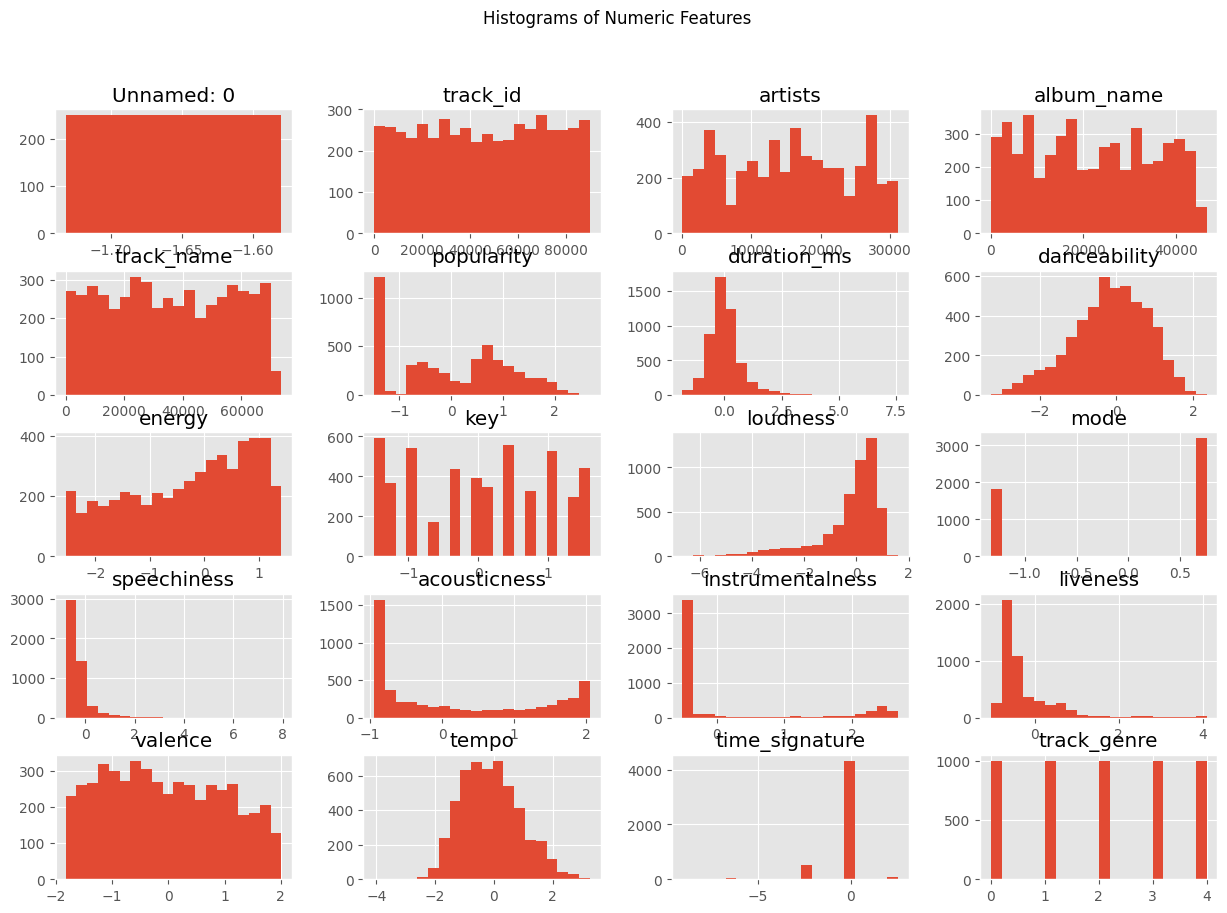

In [14]:
numeric_columns = df.select_dtypes(include=['int64','float64']).columns

df[numeric_columns].hist(
    figsize=(15,10),
    bins=20
)

plt.suptitle("Histograms of Numeric Features")
plt.show()

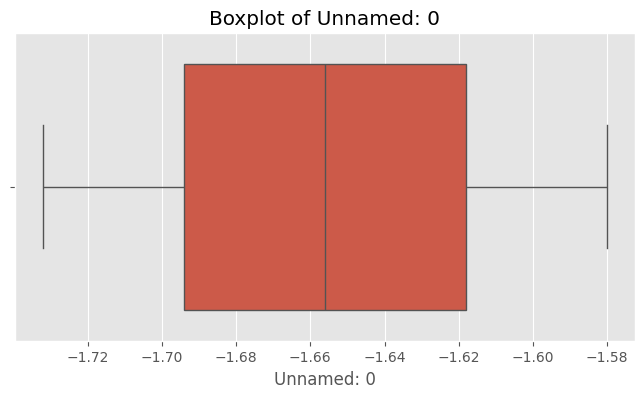

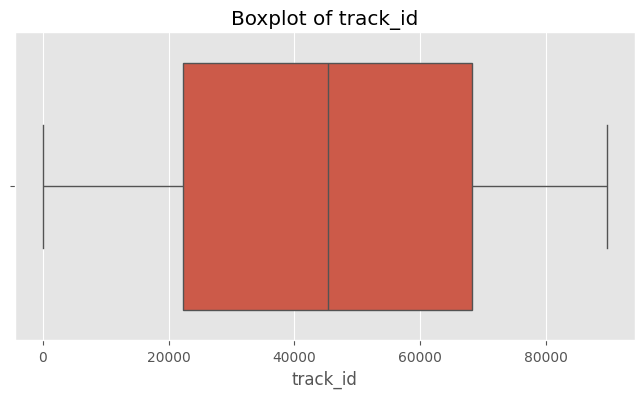

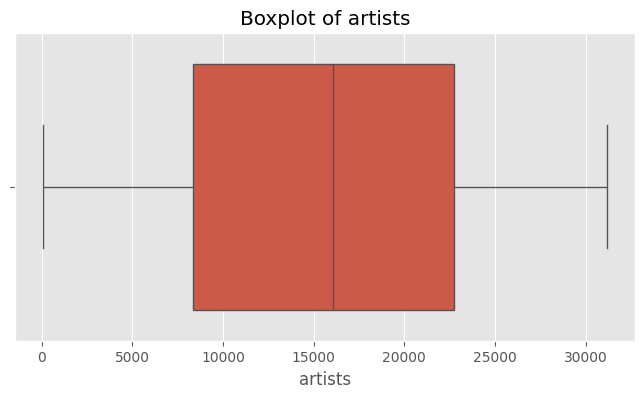

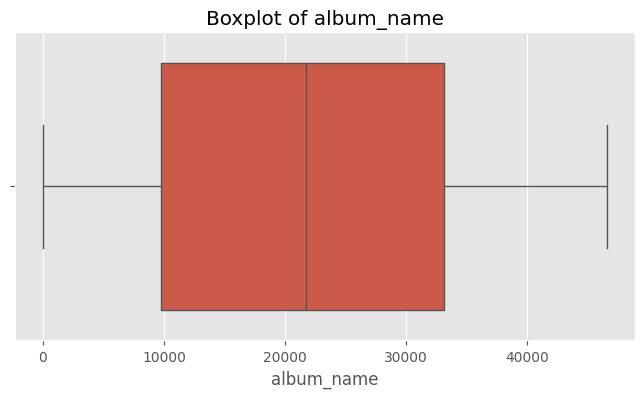

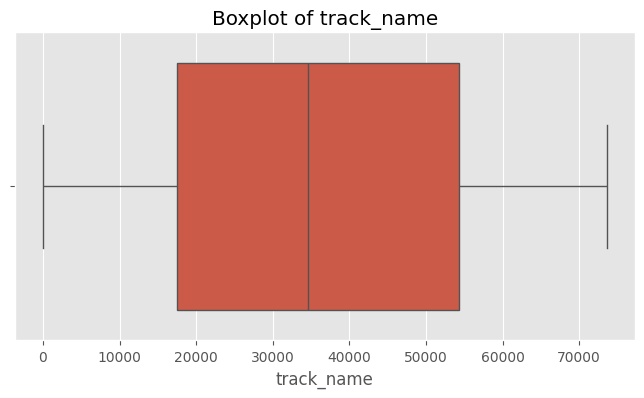

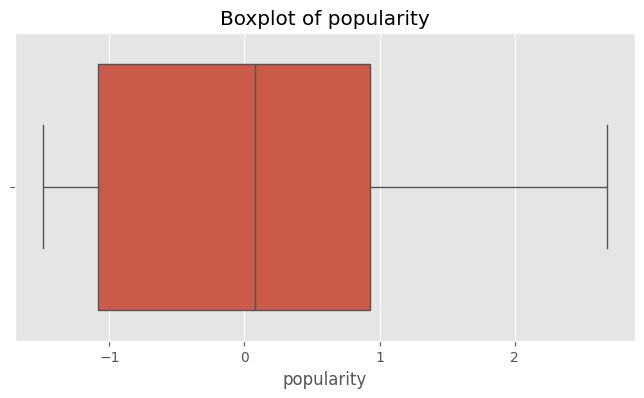

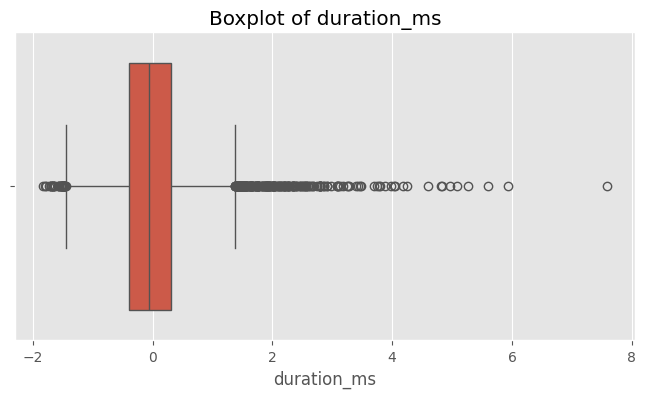

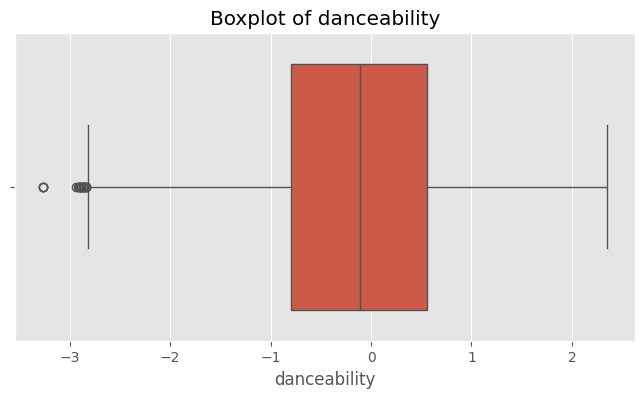

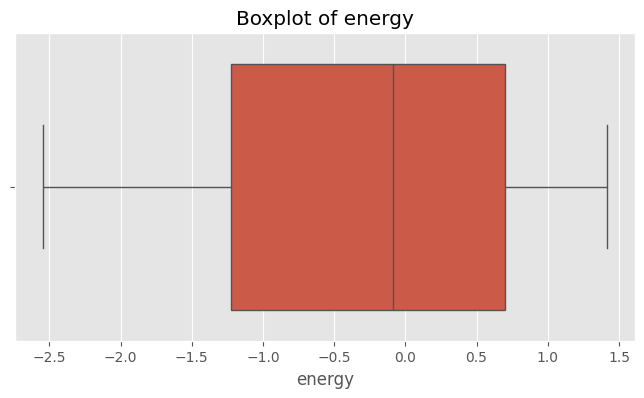

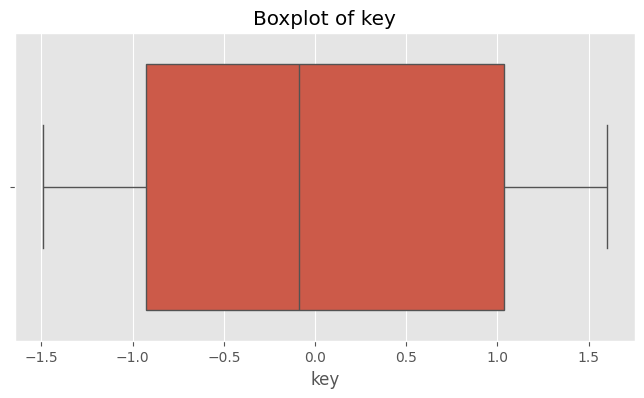

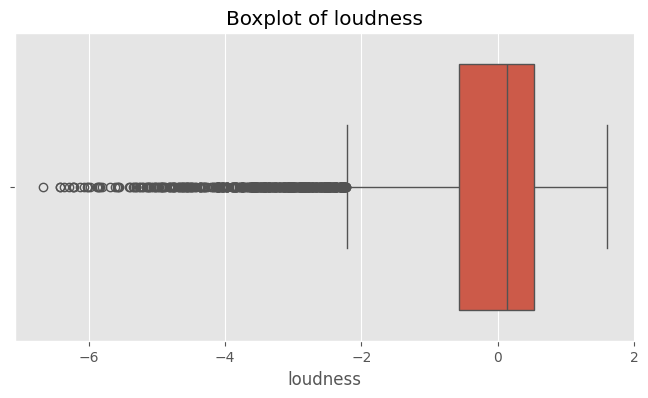

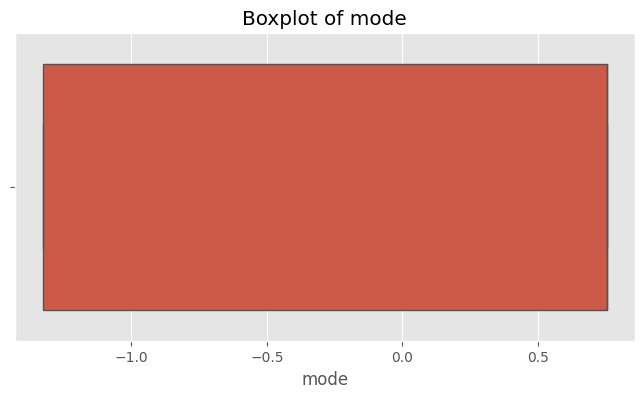

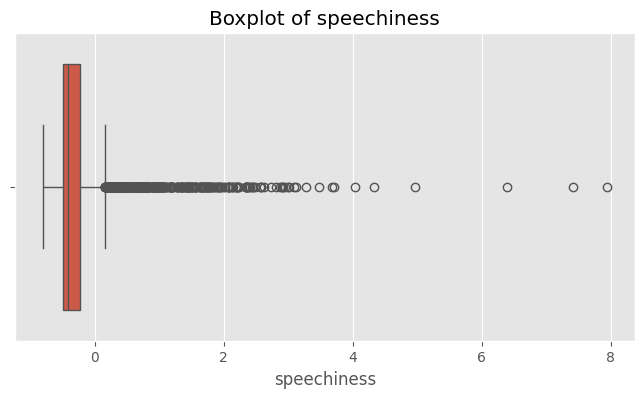

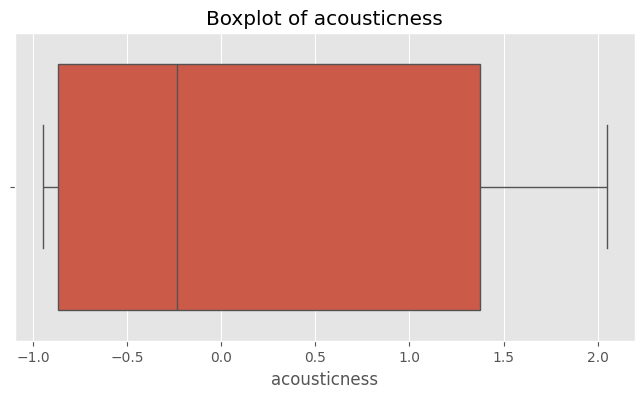

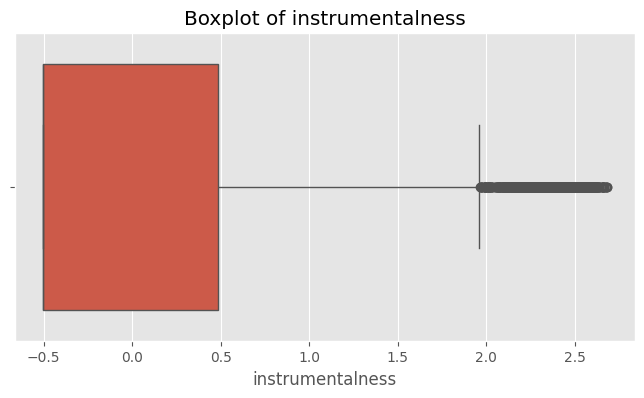

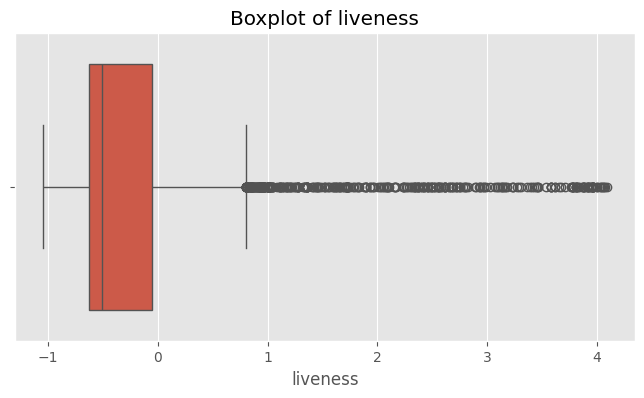

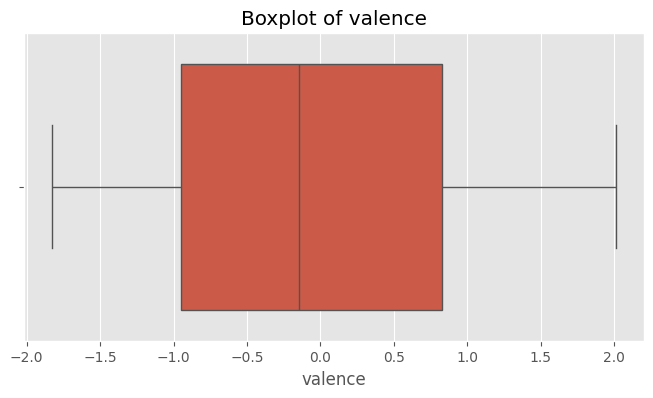

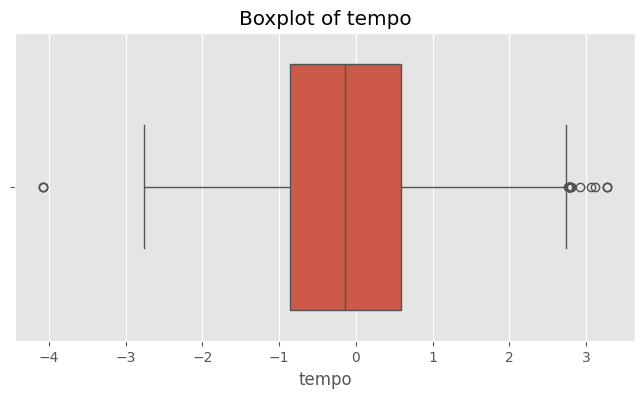

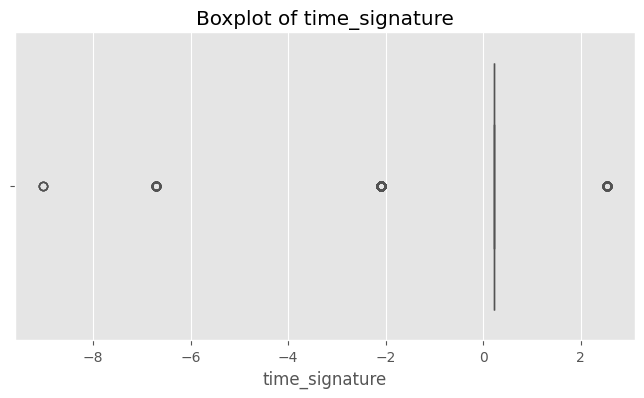

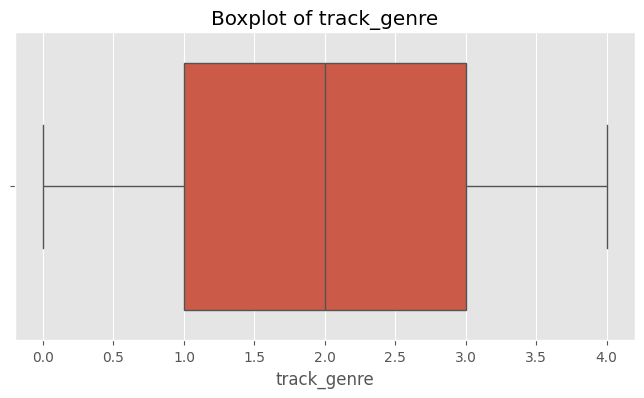

In [15]:
for col in numeric_columns:

    plt.figure(figsize=(8,4))

    sns.boxplot(x=df[col])

    plt.title(f"Boxplot of {col}")

    plt.show()

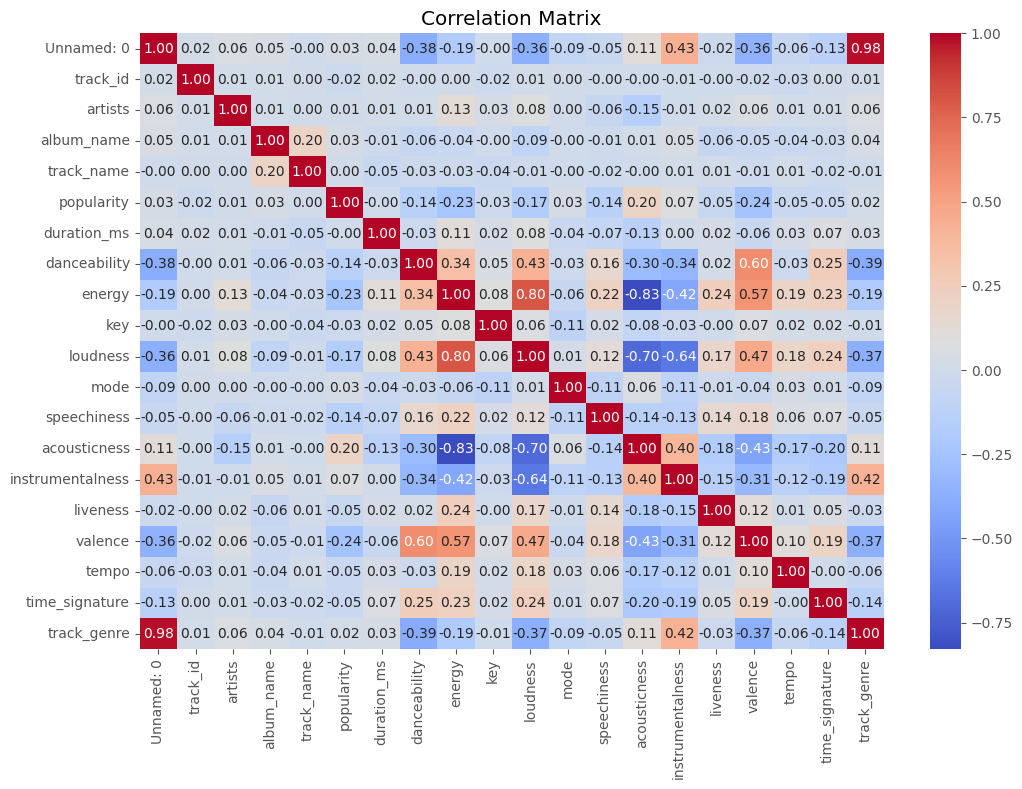

In [16]:
  plt.figure(figsize=(12,8))

corr_matrix = df[numeric_columns].corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Matrix")

plt.show()

In [ ]:
sample_df = df.sample(200)

sns.pairplot(sample_df[numeric_columns])

plt.show()

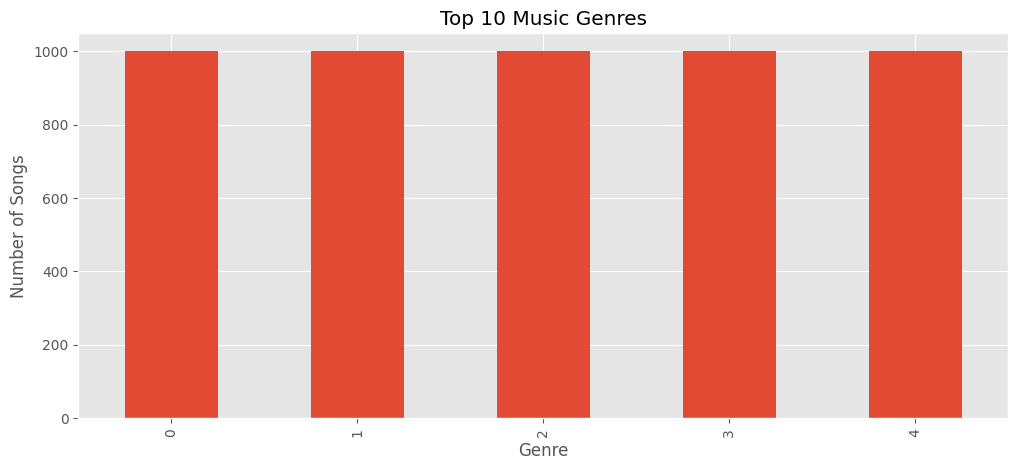

In [9]:
plt.figure(figsize=(12,5))

df['track_genre'].value_counts().head(10).plot(
    kind='bar'
)

plt.title("Top 10 Music Genres")
plt.xlabel("Genre")
plt.ylabel("Number of Songs")

plt.show()

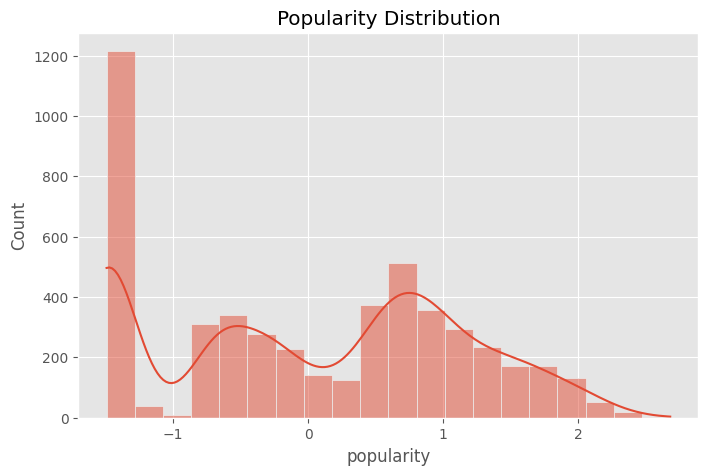

In [8]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['popularity'],
    bins=20,
    kde=True
)

plt.title("Popularity Distribution")

plt.show()

In [7]:
top_songs = df[
    ['track_name','artists','popularity']
].sort_values(
    by='popularity',
    ascending=False
)

top_songs.head(10)

,track_name,artists,popularity
3003,56201,27421,2.679288
2003,56201,27421,2.679288
2000,13232,27421,2.410290
3300,38213,20458,2.410290
3000,13232,27421,2.410290
3257,38966,27319,2.365457
3004,68419,10131,2.365457
2002,53809,27421,2.365457
2106,38966,27319,2.365457
3002,53809,27421,2.365457


In [5]:
# Keep only first 5000 rows
small_df = df.head(5000)

small_df.to_csv("spotify_small.csv", index=False)

print("Smaller file created!")

Smaller file created!
